In [9]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from pandas import read_excel

pd.set_option('display.max_columns', None)

In [10]:
df = pd.read_excel('data/Обращения_1931.xlsx')
df.head()

,Номер запроса,Дата регистрации,Статус,Пользователь,Услуга,Компонент услуги 1 уровня,Вид запроса,Тип запроса,Описание 2,Критичность,Срочность,Приоритет,Класс обслуживания,Часовой пояс запроса,Норматив ное время обработки (SLA),Плановое время выполнения,Крайний срок обработки,Фактическое время выполнения,Фактическая длительность выполнения запроса (SLA),Просрочен?*,Время входа в статус,Дата последнего изменения,Суммарное время реакции 1 линии,Суммарное время работы 1 линии,Суммарное время реакции 2 линии,Суммарное время работы 2 линии,Суммарное время реакции 3 линии,Суммарное время работы 3 линии,Суммарное время реакции 4 линии,Суммарное время работы 4 линии,Суммарное время уточнений,Результат работ,Кем решен (группа),Количество уточнений
0,37811141,2025-01-03 18:12:04.301,Закрыт,Внешний пользователь,Партионный прием (Priem.pochta.ru),Запросы из почты,Проблема из почты,Инцидент,Тема письма: Тема отсутствует. Текст письма: ...,Средняя,Низкая,(1) Наивысший,График объекта обслуживания с учетом календаря...,Москва,24:00:00,2025-01-05 00:00:00.000,2025-01-05 00:00:00,2025-01-09 12:15:09.879,60:15:09,Просрочен,2025-01-14 12:31:34.411,2025-12-15 21:23:50.557,00:00:00,00:00:00,00:00:00,00:00:00,57:24:59,02:50:10,00:00:00,00:00:00,00:00:00,Решение предоставлено,(3 линия),0
1,37811296,2025-01-03 19:32:02.428,Закрыт,Внешний пользователь,Партионный прием (Priem.pochta.ru),Запросы из почты,Проблема из почты,Инцидент,Тема письма: Запрос срочный! Министерство эко...,Средняя,Низкая,(1) Наивысший,График объекта обслуживания с учетом календаря...,Москва,24:00:00,2025-01-05 00:00:00.000,2025-01-05 00:00:00,2025-01-09 12:10:20.822,60:10:20,Просрочен,2025-01-14 12:31:35.118,2025-12-15 21:23:50.386,00:00:00,00:00:00,00:00:00,00:00:00,56:37:35,03:32:44,00:00:00,00:00:00,00:00:00,Решение предоставлено,(3 линия),0
2,37903661,2025-01-14 13:57:11.698,Закрыт,Внешний пользователь,Партионный прием (Priem.pochta.ru),Запросы из почты,Проблема из почты,Инцидент,Тема письма: Программа для офлайн. Текст пись...,Средняя,Низкая,(3) Средний,График объекта обслуживания с учетом календаря...,Москва,24:00:00,2025-01-24 15:20:15.830,2025-01-29 15:27:43,2025-01-23 16:23:41.109,01:03:25,Не просрочен,2025-01-28 16:31:08.609,2025-12-15 20:11:33.585,00:29:15,00:00:06,00:02:32,00:31:29,00:00:00,00:00:00,00:00:00,00:00:00,217:23:03,Решение предоставлено,(2 линия),2
3,37968424,2025-01-20 04:41:20.742,Закрыт,Внешний пользователь,Партионный прием (Priem.pochta.ru),Сервис партионного приема,Импорт списков из ЛК ЮЛ,Запрос на обслуживание,"Инн: по этому отправлению, оператор не приня...",Высокая,Низкая,(3) Средний,График объекта обслуживания с учетом календаря...,Москва,48:00:00,2025-01-22 04:41:20.742,2025-01-27 10:07:13,2025-01-20 12:37:49.954,02:58:12,Не просрочен,2025-01-25 13:05:25.844,2025-12-15 19:21:20.371,00:49:35,00:00:27,00:27:49,01:35:31,00:00:00,00:00:00,00:00:00,00:00:00,00:39:37,Решение предоставлено,(2 линия),1
4,38019652,2025-01-23 02:02:01.629,Закрыт,Внешний пользователь,Партионный прием (Priem.pochta.ru),Запросы из почты,Проблема из почты,Инцидент,Тема письма: Невыполненые обязательства Текс...,Средняя,Низкая,(3) Средний,График объекта обслуживания с учетом календаря...,Москва,24:00:00,2025-01-24 02:02:01.629,2025-01-29 02:08:52,2025-01-23 04:54:01.347,02:51:59,Не просрочен,2025-01-28 05:00:51.732,2025-12-15 18:44:10.379,00:48:05,00:12:13,00:00:24,00:49:44,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,Решение предоставлено,(1 линия),0


In [11]:
df.shape

(1931, 34)

In [12]:
df.columns

Index(['Номер запроса', 'Дата регистрации', 'Статус', 'Пользователь', 'Услуга',
       'Компонент услуги 1 уровня', 'Вид запроса', 'Тип запроса', 'Описание 2',
       'Критичность', 'Срочность', 'Приоритет', 'Класс обслуживания',
       'Часовой пояс запроса', 'Норматив ное время обработки (SLA)',
       'Плановое время выполнения', 'Крайний срок обработки',
       'Фактическое время выполнения',
       'Фактическая длительность выполнения запроса (SLA)', 'Просрочен?*',
       'Время входа в статус', 'Дата последнего изменения',
       'Суммарное время реакции 1 линии', 'Суммарное время работы 1 линии',
       'Суммарное время реакции 2 линии', 'Суммарное время работы 2 линии',
       'Суммарное время реакции 3 линии', 'Суммарное время работы 3 линии',
       'Суммарное время реакции 4 линии', 'Суммарное время работы 4 линии',
       'Суммарное время уточнений', 'Результат работ', 'Кем решен (группа)',
       'Количество уточнений'],
      dtype='str')

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1931 entries, 0 to 1930
Data columns (total 34 columns):
 #   Column                                             Non-Null Count  Dtype         
---  ------                                             --------------  -----         
 0   Номер запроса                                      1931 non-null   int64         
 1   Дата регистрации                                   1931 non-null   datetime64[us]
 2   Статус                                             1931 non-null   str           
 3   Пользователь                                       1931 non-null   str           
 4   Услуга                                             1931 non-null   str           
 5   Компонент услуги 1 уровня                          1312 non-null   str           
 6   Вид запроса                                        1931 non-null   str           
 7   Тип запроса                                        1931 non-null   str           
 8   Описание 2                   

Выделяем первые 15 категорий

In [14]:
df['Вид запроса'].value_counts().head(15)

Вид запроса
Прочее                                                    316
Отслеживание отправлений                                  226
Проблема с QR-код(подключение/отключение)                 135
Импорт списков из ЛК ЮЛ                                   101
Ошибка в приложении (восстановление работоспособности)     94
Проблема с push/sms/email                                  92
Электронные обращения                                      82
Проблема с ОПС/доставкой                                   71
Формирование и закрытие емкостей                           70
Ошибки загрузки страницы/зависания                         66
Проблема с авторизацией/ЭЗП/Бонусами/Доверенностями        56
Письма\бандероли                                           56
Импорт списков из архива ф.103 (zip-архив)                 53
Проблемы в работе Препост/PrePost                          49
Личный кабинет                                             44
Name: count, dtype: int64

In [15]:
#входят категория прочее
counts = df['Вид запроса'].value_counts()
top15 = counts[counts.index != 'Прочее'].head(15)
top15

Вид запроса
Отслеживание отправлений                                  226
Проблема с QR-код(подключение/отключение)                 135
Импорт списков из ЛК ЮЛ                                   101
Ошибка в приложении (восстановление работоспособности)     94
Проблема с push/sms/email                                  92
Электронные обращения                                      82
Проблема с ОПС/доставкой                                   71
Формирование и закрытие емкостей                           70
Ошибки загрузки страницы/зависания                         66
Проблема с авторизацией/ЭЗП/Бонусами/Доверенностями        56
Письма\бандероли                                           56
Импорт списков из архива ф.103 (zip-архив)                 53
Проблемы в работе Препост/PrePost                          49
Личный кабинет                                             44
Автодобавление почтовых отправлений                        42
Name: count, dtype: int64

In [16]:
data = df[df['Вид запроса'].isin(top15.index)].copy()
data.shape

(1237, 34)

In [17]:
#определяем целевую переменную
y = data['Вид запроса']

In [18]:
data.iloc[:3,3:7]

,Пользователь,Услуга,Компонент услуги 1 уровня,Вид запроса
3,Внешний пользователь,Партионный прием (Priem.pochta.ru),Сервис партионного приема,Импорт списков из ЛК ЮЛ
5,Внешний пользователь,Партионный прием (Priem.pochta.ru),Препост/PrePost,Проблемы в работе Препост/PrePost
8,Внешний пользователь,Партионный прием (Priem.pochta.ru),Сервис партионного приема,Импорт списков из ЛК ЮЛ


Смотрим пропуски

In [19]:
data.isna().sum().sort_values(ascending=False).head()

Компонент услуги 1 уровня    446
Описание 2                     1
Дата регистрации               0
Номер запроса                  0
Пользователь                   0
dtype: int64

проверяем константные признаки

In [20]:
data['Статус'].value_counts()

Статус
Закрыт    1237
Name: count, dtype: int64

In [21]:
df.nunique()

Номер запроса                                        1931
Дата регистрации                                     1931
Статус                                                  1
Пользователь                                            3
Услуга                                                  4
Компонент услуги 1 уровня                              12
Вид запроса                                            43
Тип запроса                                             2
Описание 2                                           1899
Критичность                                             3
Срочность                                               3
Приоритет                                               4
Класс обслуживания                                      4
Часовой пояс запроса                                   13
Норматив ное время обработки (SLA)                    448
Плановое время выполнения                            1515
Крайний срок обработки                               1507
Фактическое вр

In [22]:
data['Тип запроса'].value_counts()

Тип запроса
Запрос на обслуживание    958
Инцидент                  279
Name: count, dtype: int64

In [23]:
data.isna().sum()

Номер запроса                                          0
Дата регистрации                                       0
Статус                                                 0
Пользователь                                           0
Услуга                                                 0
Компонент услуги 1 уровня                            446
Вид запроса                                            0
Тип запроса                                            0
Описание 2                                             1
Критичность                                            0
Срочность                                              0
Приоритет                                              0
Класс обслуживания                                     0
Часовой пояс запроса                                   0
Норматив ное время обработки (SLA)                     0
Плановое время выполнения                              0
Крайний срок обработки                                 0
Фактическое время выполнения   

In [24]:
for col in df.columns:
    print(f'\n===== {col} =====')
    print('Тип:', df[col].dtype)
    print('Уникальных:', df[col].nunique())
    print(df[col].value_counts(dropna=False).head(10))


===== Номер запроса =====
Тип: int64
Уникальных: 1931
Номер запроса
37811141    1
37811296    1
37903661    1
37968424    1
38019652    1
38092908    1
38108746    1
38116960    1
38135950    1
38146410    1
Name: count, dtype: int64

===== Дата регистрации =====
Тип: datetime64[us]
Уникальных: 1931
Дата регистрации
2025-01-03 18:12:04.301    1
2025-01-03 19:32:02.428    1
2025-01-14 13:57:11.698    1
2025-01-20 04:41:20.742    1
2025-01-23 02:02:01.629    1
2025-01-29 08:47:03.479    1
2025-01-30 01:47:01.352    1
2025-01-30 11:24:15.990    1
2025-01-31 08:39:32.547    1
2025-01-31 14:32:03.839    1
Name: count, dtype: int64

===== Статус =====
Тип: str
Уникальных: 1
Статус
Закрыт    1931
Name: count, dtype: int64

===== Пользователь =====
Тип: str
Уникальных: 3
Пользователь
Внешний пользователь                 1091
Внутренний пользователь               831
Виртуальный помощник почты России       9
Name: count, dtype: int64

===== Услуга =====
Тип: str
Уникальных: 4
Услуга
Мобильное 

In [25]:
data.shape

(1237, 34)

Смотрим распределение

<Axes: xlabel='Вид запроса', ylabel='Count'>

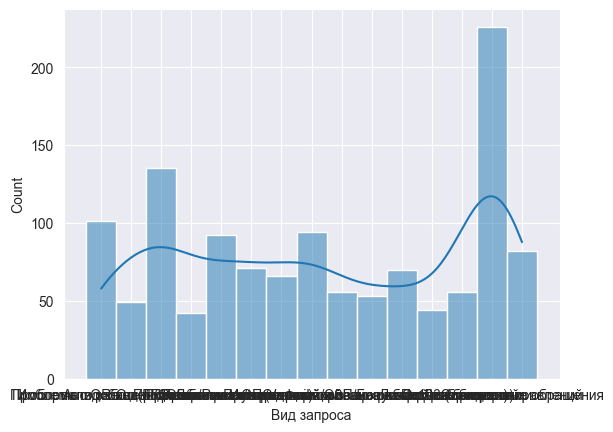

In [26]:
# распределение категорий
sns.histplot(data['Вид запроса'], kde=True)

<Axes: ylabel='Вид запроса'>

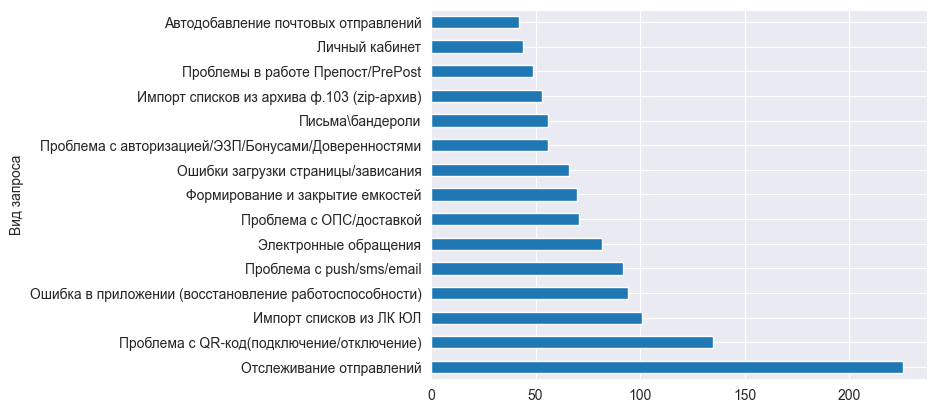

In [27]:
data['Вид запроса'].value_counts().plot(kind='barh')

Удалили 1 строук с пропуском

In [28]:
data.isna().sum()

Номер запроса                                          0
Дата регистрации                                       0
Статус                                                 0
Пользователь                                           0
Услуга                                                 0
Компонент услуги 1 уровня                            446
Вид запроса                                            0
Тип запроса                                            0
Описание 2                                             1
Критичность                                            0
Срочность                                              0
Приоритет                                              0
Класс обслуживания                                     0
Часовой пояс запроса                                   0
Норматив ное время обработки (SLA)                     0
Плановое время выполнения                              0
Крайний срок обработки                                 0
Фактическое время выполнения   

Далее проверяем влияние КАТЕГОРИАЛЬНЫХ признаков на target

In [29]:
pd.crosstab(
    data['Срочность'],
    data['Вид запроса'],
    normalize='index'
)

Вид запроса,Автодобавление почтовых отправлений,Импорт списков из ЛК ЮЛ,Импорт списков из архива ф.103 (zip-архив),Личный кабинет,Отслеживание отправлений,Ошибка в приложении (восстановление работоспособности),Ошибки загрузки страницы/зависания,Письма\бандероли,Проблема с QR-код(подключение/отключение),Проблема с push/sms/email,Проблема с ОПС/доставкой,Проблема с авторизацией/ЭЗП/Бонусами/Доверенностями,Проблемы в работе Препост/PrePost,Формирование и закрытие емкостей,Электронные обращения
Срочность,,,,,,,,,,,,,,,
Высокая,0.022727,0.146104,0.110390,0.035714,0.025974,0.110390,0.094156,0.003247,0.146104,0.068182,0.019481,0.029221,0.084416,0.103896,0.000000
Низкая,0.038106,0.058891,0.020785,0.036952,0.250577,0.054273,0.041570,0.060046,0.092379,0.071594,0.069284,0.045035,0.025404,0.040416,0.094688
Средняя,0.031746,0.079365,0.015873,0.015873,0.015873,0.206349,0.015873,0.047619,0.158730,0.142857,0.079365,0.126984,0.015873,0.047619,0.000000


Решаем не удалять большое количество пропусков а ввести отдельную категорию Не указан, т.к влияет

In [30]:
data['Компонент услуги 1 уровня'] = data['Компонент услуги 1 уровня'].fillna('Не указан')

In [31]:
pd.crosstab(
    data['Компонент услуги 1 уровня'],
    data['Вид запроса'],
    normalize='index'
)

Вид запроса,Автодобавление почтовых отправлений,Импорт списков из ЛК ЮЛ,Импорт списков из архива ф.103 (zip-архив),Личный кабинет,Отслеживание отправлений,Ошибка в приложении (восстановление работоспособности),Ошибки загрузки страницы/зависания,Письма\бандероли,Проблема с QR-код(подключение/отключение),Проблема с push/sms/email,Проблема с ОПС/доставкой,Проблема с авторизацией/ЭЗП/Бонусами/Доверенностями,Проблемы в работе Препост/PrePost,Формирование и закрытие емкостей,Электронные обращения
Компонент услуги 1 уровня,,,,,,,,,,,,,,,
Мобильное приложение,0.09292,0.000000,0.000000,0.000000,0.000000,0.207965,0.000000,0.000000,0.298673,0.20354,0.073009,0.123894,0.0,0.000000,0.000000
Не указан,0.00000,0.000000,0.000000,0.098655,0.506726,0.000000,0.000000,0.125561,0.000000,0.00000,0.085202,0.000000,0.0,0.000000,0.183857
Препост/PrePost,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,1.0,0.000000,0.000000
Сервис партионного приема,0.00000,0.348276,0.182759,0.000000,0.000000,0.000000,0.227586,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.241379,0.000000


In [32]:
data['Компонент услуги 1 уровня'].value_counts()

Компонент услуги 1 уровня
Мобильное приложение         452
Не указан                    446
Сервис партионного приема    290
Препост/PrePost               49
Name: count, dtype: int64

In [33]:
data  = data.dropna(subset=["Описание 2"])

In [34]:
pd.crosstab(
    data['Компонент услуги 1 уровня'],
    data['Вид запроса'],
    normalize='index'
)

Вид запроса,Автодобавление почтовых отправлений,Импорт списков из ЛК ЮЛ,Импорт списков из архива ф.103 (zip-архив),Личный кабинет,Отслеживание отправлений,Ошибка в приложении (восстановление работоспособности),Ошибки загрузки страницы/зависания,Письма\бандероли,Проблема с QR-код(подключение/отключение),Проблема с push/sms/email,Проблема с ОПС/доставкой,Проблема с авторизацией/ЭЗП/Бонусами/Доверенностями,Проблемы в работе Препост/PrePost,Формирование и закрытие емкостей,Электронные обращения
Компонент услуги 1 уровня,,,,,,,,,,,,,,,
Мобильное приложение,0.090909,0.000000,0.000000,0.000000,0.000000,0.208426,0.000000,0.000000,0.299335,0.203991,0.073171,0.124169,0.0,0.000000,0.000000
Не указан,0.000000,0.000000,0.000000,0.098655,0.506726,0.000000,0.000000,0.125561,0.000000,0.000000,0.085202,0.000000,0.0,0.000000,0.183857
Препост/PrePost,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.000000
Сервис партионного приема,0.000000,0.348276,0.182759,0.000000,0.000000,0.000000,0.227586,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.241379,0.000000


Поработали с пропусками, посмотрели на рапсределение категориальных признаков, далее приступаем к дубликатам

In [35]:
data.duplicated().sum()
#полных дубликатов нет
for col in data.columns:
    print(f'\n===== {col} =====')
    print(data[col].duplicated().sum())
data[data['Описание 2'].duplicated(keep=False)].head()



===== Номер запроса =====
0

===== Дата регистрации =====
0

===== Статус =====
1235

===== Пользователь =====
1233

===== Услуга =====
1232

===== Компонент услуги 1 уровня =====
1232

===== Вид запроса =====
1221

===== Тип запроса =====
1234

===== Описание 2 =====
16

===== Критичность =====
1233

===== Срочность =====
1233

===== Приоритет =====
1232

===== Класс обслуживания =====
1233

===== Часовой пояс запроса =====
1223

===== Норматив ное время обработки (SLA) =====
909

===== Плановое время выполнения =====
223

===== Крайний срок обработки =====
227

===== Фактическое время выполнения =====
0

===== Фактическая длительность выполнения запроса (SLA) =====
333

===== Просрочен?* =====
1234

===== Время входа в статус =====
0

===== Дата последнего изменения =====
0

===== Суммарное время реакции 1 линии =====
533

===== Суммарное время работы 1 линии =====
623

===== Суммарное время реакции 2 линии =====
853

===== Суммарное время работы 2 линии =====
770

===== Суммарное в

,Номер запроса,Дата регистрации,Статус,Пользователь,Услуга,Компонент услуги 1 уровня,Вид запроса,Тип запроса,Описание 2,Критичность,Срочность,Приоритет,Класс обслуживания,Часовой пояс запроса,Норматив ное время обработки (SLA),Плановое время выполнения,Крайний срок обработки,Фактическое время выполнения,Фактическая длительность выполнения запроса (SLA),Просрочен?*,Время входа в статус,Дата последнего изменения,Суммарное время реакции 1 линии,Суммарное время работы 1 линии,Суммарное время реакции 2 линии,Суммарное время работы 2 линии,Суммарное время реакции 3 линии,Суммарное время работы 3 линии,Суммарное время реакции 4 линии,Суммарное время работы 4 линии,Суммарное время уточнений,Результат работ,Кем решен (группа),Количество уточнений
35,38543952,2025-03-01 15:11:52.648,Закрыт,Внутренний пользователь,"Мобильное приложение ""Почта России""",Мобильное приложение,Проблема с push/sms/email,Запрос на обслуживание,Ответ на п--- Клиенту код для подключения серв...,Низкая,Низкая,(4) Низкий,5х8 (9:00-13:00 - 14:00-18:00),Москва,120:00:00,2025-03-21 18:00:00.000,2025-03-21 18:00:00,2025-03-01 15:15:26.448,00:00:00,Не просрочен,2025-03-06 15:32:35.686,2025-12-15 12:09:09.659,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,Дублирование,(1 линия),0
36,38543974,2025-03-01 15:15:13.319,Закрыт,Внешний пользователь,"Мобильное приложение ""Почта России""",Мобильное приложение,Проблема с push/sms/email,Запрос на обслуживание,Ответ на п--- Клиенту код для подключения серв...,Низкая,Низкая,(4) Низкий,5х8 (9:00-13:00 - 14:00-18:00),Москва,120:00:00,2025-03-28 18:00:00.000,2025-03-28 18:00:00,2025-03-09 19:33:56.283,00:00:00,Не просрочен,2025-03-09 19:33:56.223,2025-12-15 12:09:09.225,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,40:00:00,По сроку давности,(1 линия),1
453,38641575,2025-03-07 12:14:37.565,Закрыт,Внутренний пользователь,Партионный прием (Priem.pochta.ru),Сервис партионного приема,Импорт списков из ЛК ЮЛ,Запрос на обслуживание,"ОПЕРАТОР РАНО ЗАКРЫЛА СПИСОК,ОСТАЛИСЬ НЕПРИНЯТ...",Высокая,Низкая,(3) Средний,График объекта обслуживания с учетом календаря...,Екатеринбург,122:59:22,2025-03-12 15:13:59.565,2025-03-12 15:13:59,2025-03-07 13:09:13.973,00:55:00,Не просрочен,2025-03-12 13:33:09.361,2025-12-15 10:56:50.295,00:01:21,00:00:08,00:00:33,00:52:30,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,Решение предоставлено,(2 линия),0
457,38642067,2025-03-07 12:40:12.902,Закрыт,Внутренний пользователь,Партионный прием (Priem.pochta.ru),Сервис партионного приема,Формирование и закрытие емкостей,Инцидент,"ОПЕРАТОР РАНО ЗАКРЫЛА СПИСОК,ОСТАЛИСЬ НЕПРИНЯТ...",Высокая,Низкая,(3) Средний,График объекта обслуживания с учетом календаря...,Екатеринбург,74:59:47,2025-03-10 15:39:59.902,2025-03-10 15:39:59,2025-03-07 12:45:10.074,00:05:00,Не просрочен,2025-03-12 13:04:31.011,2025-12-15 10:56:41.453,00:00:05,00:00:07,00:00:10,00:04:32,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,Дублирование,(2 линия),0
523,38646853,2025-03-09 09:29:41.662,Закрыт,Внутренний пользователь,"Мобильное приложение ""Почта России""",Мобильное приложение,Ошибка в приложении (восстановление работоспос...,Инцидент,Л--- А--- В моем приложении отсутствуют ИСХОДЯ...,Высокая,Средняя,(2) Высокий,5х8 (9:00-13:00 - 14:00-18:00),Москва,40:00:00,2025-03-19 18:00:00.000,2025-03-19 18:00:00,2025-03-13 06:35:05.303,00:00:00,Не просрочен,2025-03-13 06:35:05.132,2025-12-15 10:53:16.682,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,24:00:00,По сроку давности,(1 линия),1


Если у таких строк одинаковый вид запроса и они попадаут в разные выборки то метрика будет слишком оптимистичной нужно проверить это

In [36]:
desc_target= (data.groupby('Описание 2')['Вид запроса'].nunique())
desc_target.value_counts()

Вид запроса
1    1217
2       3
Name: count, dtype: int64

In [37]:
data.shape

(1236, 34)

In [38]:
conflict_desc= desc_target[desc_target>1].index

data[data['Описание 2'].isin(conflict_desc)].sort_values('Описание 2')

,Номер запроса,Дата регистрации,Статус,Пользователь,Услуга,Компонент услуги 1 уровня,Вид запроса,Тип запроса,Описание 2,Критичность,Срочность,Приоритет,Класс обслуживания,Часовой пояс запроса,Норматив ное время обработки (SLA),Плановое время выполнения,Крайний срок обработки,Фактическое время выполнения,Фактическая длительность выполнения запроса (SLA),Просрочен?*,Время входа в статус,Дата последнего изменения,Суммарное время реакции 1 линии,Суммарное время работы 1 линии,Суммарное время реакции 2 линии,Суммарное время работы 2 линии,Суммарное время реакции 3 линии,Суммарное время работы 3 линии,Суммарное время реакции 4 линии,Суммарное время работы 4 линии,Суммарное время уточнений,Результат работ,Кем решен (группа),Количество уточнений
1080,38885050,2025-03-27 14:35:26.417,Закрыт,Внутренний пользователь,Партионный прием (Priem.pochta.ru),Сервис партионного приема,Импорт списков из ЛК ЮЛ,Запрос на обслуживание,Добрый день! Оператор при приеме списка № от ....,Высокая,Низкая,(3) Средний,График объекта обслуживания с учетом календаря...,Москва,161:59:33,2025-04-03 08:34:59.417,2025-04-03 08:34:59,2025-03-27 15:11:30.144,00:36:00,Не просрочен,2025-04-01 15:34:19.485,2025-12-15 07:53:39.684,00:00:05,00:00:06,00:00:38,00:35:12,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,Решение предоставлено,(2 линия),0
1085,38885982,2025-03-27 15:26:53.360,Закрыт,Внутренний пользователь,Партионный прием (Priem.pochta.ru),Сервис партионного приема,Ошибки загрузки страницы/зависания,Инцидент,Добрый день! Оператор при приеме списка № от ....,Высокая,Низкая,(3) Средний,График объекта обслуживания с учетом календаря...,Москва,95:59:06,2025-03-31 15:25:59.360,2025-03-31 15:25:59,2025-03-27 15:37:48.951,00:11:00,Не просрочен,2025-04-01 16:03:38.766,2025-12-15 07:53:26.844,00:00:16,00:02:51,00:00:38,00:07:08,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,Дублирование,(2 линия),0
453,38641575,2025-03-07 12:14:37.565,Закрыт,Внутренний пользователь,Партионный прием (Priem.pochta.ru),Сервис партионного приема,Импорт списков из ЛК ЮЛ,Запрос на обслуживание,"ОПЕРАТОР РАНО ЗАКРЫЛА СПИСОК,ОСТАЛИСЬ НЕПРИНЯТ...",Высокая,Низкая,(3) Средний,График объекта обслуживания с учетом календаря...,Екатеринбург,122:59:22,2025-03-12 15:13:59.565,2025-03-12 15:13:59,2025-03-07 13:09:13.973,00:55:00,Не просрочен,2025-03-12 13:33:09.361,2025-12-15 10:56:50.295,00:01:21,00:00:08,00:00:33,00:52:30,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,Решение предоставлено,(2 линия),0
457,38642067,2025-03-07 12:40:12.902,Закрыт,Внутренний пользователь,Партионный прием (Priem.pochta.ru),Сервис партионного приема,Формирование и закрытие емкостей,Инцидент,"ОПЕРАТОР РАНО ЗАКРЫЛА СПИСОК,ОСТАЛИСЬ НЕПРИНЯТ...",Высокая,Низкая,(3) Средний,График объекта обслуживания с учетом календаря...,Екатеринбург,74:59:47,2025-03-10 15:39:59.902,2025-03-10 15:39:59,2025-03-07 12:45:10.074,00:05:00,Не просрочен,2025-03-12 13:04:31.011,2025-12-15 10:56:41.453,00:00:05,00:00:07,00:00:10,00:04:32,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,Дублирование,(2 линия),0
1112,38890161,2025-03-28 06:36:07.271,Закрыт,Внешний пользователь,"Мобильное приложение ""Почта России""",Мобильное приложение,Ошибка в приложении (восстановление работоспос...,Инцидент,Тема письма: Тема отсутствует. Текст письма: ...,Высокая,Низкая,(3) Средний,5х8 (9:00-13:00 - 14:00-18:00),Москва,40:00:00,2025-04-11 18:00:00.000,2025-04-11 18:00:00,2025-04-06 09:05:59.692,00:00:00,Не просрочен,2025-04-06 09:05:59.628,2025-12-15 07:50:45.334,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,48:00:00,Не согласован,(1 линия),4
1619,40507147,2025-08-12 09:50:04.088,Закрыт,Внешний пользователь,Портал pochta.ru,Не указан,Электронные обращения,Запрос на обслуживание,Тема письма: Тема отсутствует. Текст письма: ...,Средняя,Низкая,(3) Средний,"5x9 (Пн-Чт 9:00-18:00, Пт 9:00-16:45)",Москва,120:00:00,2025-08-29 15:20:04.088,2025-08-29 15:20:04,2025-08-12 10:01:52.083,00:11:47,Не просрочен,2025-08-12 10:01:52.025,2025-12-14 14:40:31.530,00:00:3

In [39]:
description_counts = data['Описание 2'].value_counts()

description_counts.value_counts()

count
1    1206
2      12
3       2
Name: count, dtype: int64

In [40]:
data.head()

,Номер запроса,Дата регистрации,Статус,Пользователь,Услуга,Компонент услуги 1 уровня,Вид запроса,Тип запроса,Описание 2,Критичность,Срочность,Приоритет,Класс обслуживания,Часовой пояс запроса,Норматив ное время обработки (SLA),Плановое время выполнения,Крайний срок обработки,Фактическое время выполнения,Фактическая длительность выполнения запроса (SLA),Просрочен?*,Время входа в статус,Дата последнего изменения,Суммарное время реакции 1 линии,Суммарное время работы 1 линии,Суммарное время реакции 2 линии,Суммарное время работы 2 линии,Суммарное время реакции 3 линии,Суммарное время работы 3 линии,Суммарное время реакции 4 линии,Суммарное время работы 4 линии,Суммарное время уточнений,Результат работ,Кем решен (группа),Количество уточнений
3,37968424,2025-01-20 04:41:20.742,Закрыт,Внешний пользователь,Партионный прием (Priem.pochta.ru),Сервис партионного приема,Импорт списков из ЛК ЮЛ,Запрос на обслуживание,"Инн: по этому отправлению, оператор не приня...",Высокая,Низкая,(3) Средний,График объекта обслуживания с учетом календаря...,Москва,48:00:00,2025-01-22 04:41:20.742,2025-01-27 10:07:13,2025-01-20 12:37:49.954,02:58:12,Не просрочен,2025-01-25 13:05:25.844,2025-12-15 19:21:20.371,00:49:35,00:00:27,00:27:49,01:35:31,00:00:00,00:00:00,00:00:00,00:00:00,00:39:37,Решение предоставлено,(2 линия),1
5,38092908,2025-01-29 08:47:03.479,Закрыт,Внешний пользователь,Партионный прием (Priem.pochta.ru),Препост/PrePost,Проблемы в работе Препост/PrePost,Инцидент,Тема письма: По номеру договора при вводе отпр...,Низкая,Низкая,(1) Наивысший,График объекта обслуживания с учетом календаря...,Москва,24:00:00,2025-01-30 08:47:03.479,2025-01-30 08:47:03,2025-01-30 11:42:44.107,25:45:32,Просрочен,2025-02-04 12:01:51.695,2025-12-15 17:47:41.311,00:06:15,00:24:56,22:31:19,00:06:03,00:00:55,00:33:53,00:00:00,00:00:00,01:10:07,Решение предоставлено,(3 линия),2
8,38135950,2025-01-31 08:39:32.547,Закрыт,Внешний пользователь,Партионный прием (Priem.pochta.ru),Сервис партионного приема,Импорт списков из ЛК ЮЛ,Запрос на обслуживание,Инн: Пользо--- добавил комментарий: Пришлит...,Высокая,Низкая,(3) Средний,График объекта обслуживания с учетом календаря...,Москва,48:00:00,2025-02-14 03:03:28.289,2025-02-19 03:08:20,2025-02-12 07:55:48.931,04:52:20,Не просрочен,2025-02-17 08:00:41.337,2025-12-15 17:14:54.840,00:21:50,00:20:12,00:55:23,00:05:14,00:00:00,00:00:00,00:00:00,00:00:00,282:03:28,Решение предоставлено,(2 линия),1
10,38539821,2025-03-01 02:48:43.455,Закрыт,Внутренний пользователь,"Мобильное приложение ""Почта России""",Мобильное приложение,Проблема с QR-код(подключение/отключение),Запрос на обслуживание,"Здравствуйте. Коллеги, ответ необходимо предос...",Низкая,Средняя,(4) Низкий,5х8 (9:00-13:00 - 14:00-18:00),Москва,120:00:00,2025-03-21 18:00:00.000,2025-03-21 18:00:00,2025-03-01 03:27:16.293,00:00:00,Не просрочен,2025-03-06 03:30:39.543,2025-12-15 12:17:06.031,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,Дублирование,(1 линия),0
11,38539850,2025-03-01 03:26:30.062,Закрыт,Внешний пользователь,"Мобильное приложение ""Почта России""",Мобильное приложение,Проблема с QR-код(подключение/отключение),Запрос на обслуживание,"Здравствуйте. Коллеги, ответ необходимо предос...",Низкая,Низкая,(4) Низкий,5х8 (9:00-13:00 - 14:00-18:00),Москва,120:00:00,2025-03-25 09:56:06.167,2025-03-25 09:56:06,2025-03-05 01:24:19.806,07:03:53,Не просрочен,2025-03-10 01:30:36.584,2025-12-15 12:12:28.430,00:00:00,07:03:53,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,08:56:06,Решение предоставлено,(1 линия),1


In [41]:
temp = data[['Услуга','Пользователь','Компонент услуги 1 уровня','Описание 2','Критичность','Тип запроса','Вид запроса','Срочность','Приоритет','Класс обслуживания']].duplicated(keep= False)

In [42]:
data[temp].shape

(12, 34)

In [43]:
data[temp]

,Номер запроса,Дата регистрации,Статус,Пользователь,Услуга,Компонент услуги 1 уровня,Вид запроса,Тип запроса,Описание 2,Критичность,Срочность,Приоритет,Класс обслуживания,Часовой пояс запроса,Норматив ное время обработки (SLA),Плановое время выполнения,Крайний срок обработки,Фактическое время выполнения,Фактическая длительность выполнения запроса (SLA),Просрочен?*,Время входа в статус,Дата последнего изменения,Суммарное время реакции 1 линии,Суммарное время работы 1 линии,Суммарное время реакции 2 линии,Суммарное время работы 2 линии,Суммарное время реакции 3 линии,Суммарное время работы 3 линии,Суммарное время реакции 4 линии,Суммарное время работы 4 линии,Суммарное время уточнений,Результат работ,Кем решен (группа),Количество уточнений
523,38646853,2025-03-09 09:29:41.662,Закрыт,Внутренний пользователь,"Мобильное приложение ""Почта России""",Мобильное приложение,Ошибка в приложении (восстановление работоспос...,Инцидент,Л--- А--- В моем приложении отсутствуют ИСХОДЯ...,Высокая,Средняя,(2) Высокий,5х8 (9:00-13:00 - 14:00-18:00),Москва,40:00:00,2025-03-19 18:00:00.000,2025-03-19 18:00:00,2025-03-13 06:35:05.303,00:00:00,Не просрочен,2025-03-13 06:35:05.132,2025-12-15 10:53:16.682,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,24:00:00,По сроку давности,(1 линия),1
524,38646858,2025-03-09 09:35:53.142,Закрыт,Внутренний пользователь,"Мобильное приложение ""Почта России""",Мобильное приложение,Ошибка в приложении (восстановление работоспос...,Инцидент,Л--- А--- В моем приложении отсутствуют ИСХОДЯ...,Высокая,Средняя,(2) Высокий,5х8 (9:00-13:00 - 14:00-18:00),Москва,40:00:00,2025-03-14 18:00:00.000,2025-03-14 18:00:00,2025-03-09 09:43:35.090,00:00:00,Не просрочен,2025-03-09 09:43:35.021,2025-12-15 10:53:16.639,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,По сроку давности,(1 линия),0
946,38785727,2025-03-19 19:26:49.753,Закрыт,Внутренний пользователь,Партионный прием (Priem.pochta.ru),Сервис партионного приема,Импорт списков из ЛК ЮЛ,Запрос на обслуживание,Добрый день. Не можем принять рпо по Ф. ...,Высокая,Высокая,(1) Наивысший,График объекта обслуживания с учетом календаря...,Москва,99:47:41,2025-03-27 11:52:59.753,2025-03-27 11:52:59,2025-03-23 08:11:54.676,00:07:00,Не просрочен,2025-03-28 08:30:46.706,2025-12-15 09:08:40.261,00:00:55,00:00:32,00:00:53,00:05:14,00:00:00,00:00:00,00:00:00,00:00:00,84:37:27,Решение предоставлено,(2 линия),1
947,38785924,2025-03-19 21:21:57.380,Закрыт,Внутренний пользователь,Партионный прием (Priem.pochta.ru),Сервис партионного приема,Импорт списков из ЛК ЮЛ,Запрос на обслуживание,Добрый день. Не можем принять рпо по Ф. ...,Высокая,Высокая,(1) Наивысший,График объекта обслуживания с учетом календаря...,Москва,114:38:02,2025-03-24 15:59:59.380,2025-03-24 15:59:59,2025-03-19 22:09:01.585,00:00:00,Не просрочен,2025-03-24 22:31:13.855,2025-12-15 09:08:36.572,00:01:38,00:00:59,00:01:43,00:42:41,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,Решение предоставлено,(2 линия),0
948,38785928,2025-03-19 21:23:43.826,Закрыт,Внутренний пользователь,Партионный прием (Priem.pochta.ru),Сервис партионного приема,Импорт списков из ЛК ЮЛ,Запрос на обслуживание,Добрый день. Не можем принять рпо по Ф. ...,Высокая,Высокая,(1) Наивысший,График объекта обслуживания с учетом календаря...,Москва,114:36:16,2025-03-24 15:59:59.826,2025-03-24 15:59:59,2025-03-19 21:34:10.296,00:00:00,Не просрочен,2025-03-24 22:01:12.427,2025-12-15 09:08:36.556,00:01:24,00:00:10,00:06:37,00:02:13,00:00:00,00:00:00,00:00:00,00:00:00,00:00:00,Дублирование,(2 линия),0
1022,38850260,2025-03-25 13:26:08.365,Закрыт,Внутренний пользователь,Партионный прием (Priem.pochta.ru),Препост/PrePost,Проблемы в работе Препост/PrePost,Инцидент,созданный файл не грузится в ЛК,Низкая,Низкая,(4) Низкий,График объекта обслуживания с учетом календаря...,Москва,50:33:51,2025-03-27 15:59:59.365,2025-03-27 15:59:59,2025-03-25 15:06:33.870,01:06:00,Не просрочен,2025-03-27 10:41:09.492,2025-12-15 08:20:32.639,00:0

In [44]:
data = data.drop_duplicates(
    subset=[
        'Услуга',
        'Пользователь',
        'Компонент услуги 1 уровня',
        'Описание 2',
        'Критичность',
        'Тип запроса',
        'Вид запроса',
        'Срочность',
        'Приоритет',
        'Класс обслуживания',
    ],
    keep='first',
)

In [45]:
data.shape

(1229, 34)

<Axes: xlabel='Срочность', ylabel='count'>

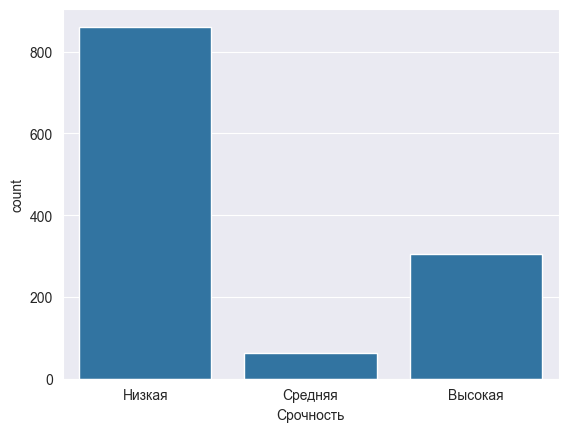

In [46]:
sns.countplot(x ='Срочность', data=data)

In [47]:
pd.crosstab(data['Тип запроса'], data['Вид запроса'])

Вид запроса,Автодобавление почтовых отправлений,Импорт списков из ЛК ЮЛ,Импорт списков из архива ф.103 (zip-архив),Личный кабинет,Отслеживание отправлений,Ошибка в приложении (восстановление работоспособности),Ошибки загрузки страницы/зависания,Письма\бандероли,Проблема с QR-код(подключение/отключение),Проблема с push/sms/email,Проблема с ОПС/доставкой,Проблема с авторизацией/ЭЗП/Бонусами/Доверенностями,Проблемы в работе Препост/PrePost,Формирование и закрытие емкостей,Электронные обращения
Тип запроса,,,,,,,,,,,,,,,
Запрос на обслуживание,41,99,53,44,226,0,0,56,135,92,71,56,0,0,79
Инцидент,0,0,0,0,0,93,66,0,0,0,0,0,48,70,0


Добавляем новые признаки

In [48]:
data['Длина текста'] = data['Описание 2'].apply(lambda x: len(x))
data['Длина текста']


3       496
5       196
8       305
10      156
11      167
       ... 
1920    461
1921    679
1924    456
1925    698
1927    511
Name: Длина текста, Length: 1229, dtype: int64

<Axes: xlabel='Срочность', ylabel='Длина текста'>

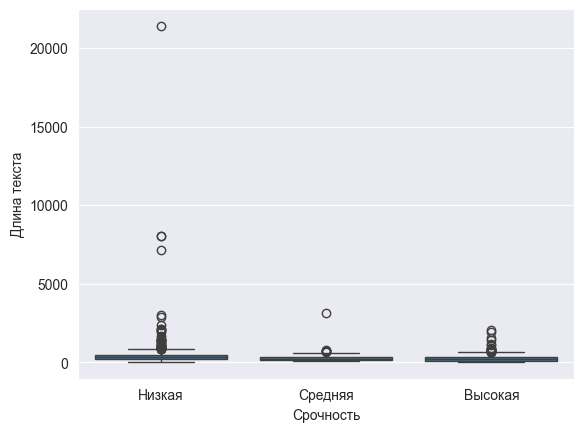

In [49]:
sns.boxplot(data=data, y='Длина текста', x='Срочность')

<Axes: xlabel='Приоритет', ylabel='Длина текста'>

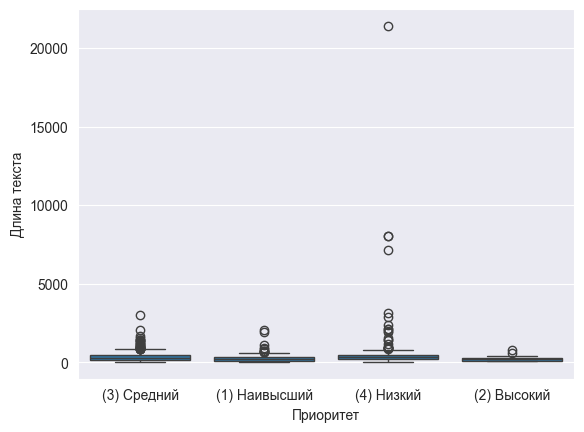

In [50]:
sns.boxplot(data=data, x= 'Приоритет', y='Длина текста')

<Axes: ylabel='Длина текста'>

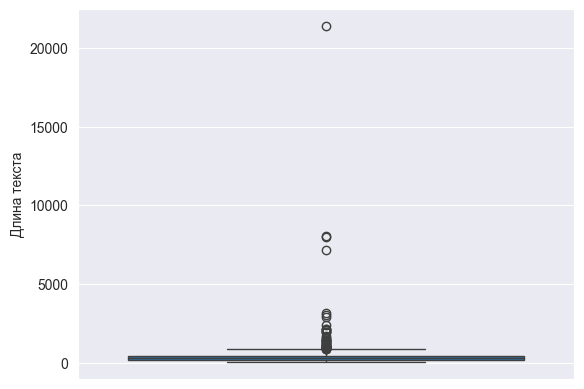

In [51]:
sns.boxplot(
    data=data,
    y='Длина текста'
)


<Axes: xlabel='Длина текста', ylabel='Вид запроса'>

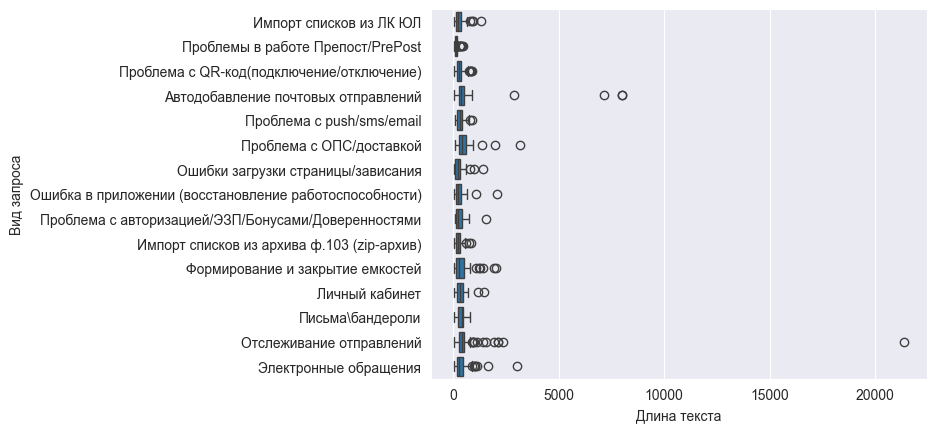

In [52]:
sns.boxplot(data=data, y= 'Вид запроса', x='Длина текста')

In [53]:
pd.crosstab(data['Вид запроса'], data['Количество уточнений'])

Количество уточнений,0,1,2,3,4,5,6,7,9,10
Вид запроса,,,,,,,,,,
Автодобавление почтовых отправлений,9,17,6,5,3,1,0,0,0,0
Импорт списков из ЛК ЮЛ,53,24,17,3,1,1,0,0,0,0
Импорт списков из архива ф.103 (zip-архив),15,23,8,3,2,0,1,0,0,1
Личный кабинет,21,15,6,0,0,1,1,0,0,0
Отслеживание отправлений,108,77,29,9,2,1,0,0,0,0
Ошибка в приложении (восстановление работоспособности),27,45,12,5,2,1,0,0,1,0
Ошибки загрузки страницы/зависания,18,15,17,6,3,5,1,0,1,0
Письма\бандероли,14,35,3,2,2,0,0,0,0,0
Проблема с QR-код(подключение/отключение),39,74,16,5,0,1,0,0,0,0


<Axes: xlabel='Количество уточнений', ylabel='count'>

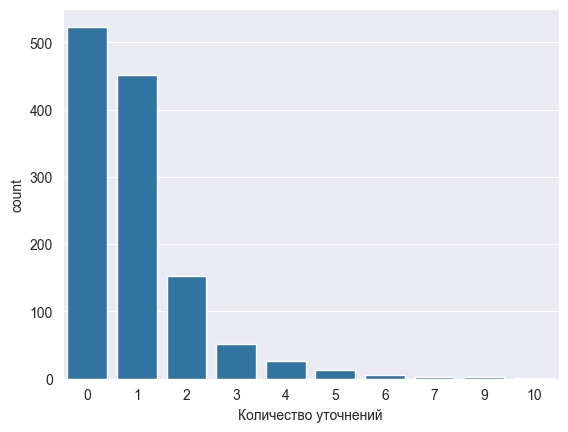

In [54]:
sns.countplot(
    data=data,
    x='Количество уточнений'
)

<Axes: xlabel='Срочность'>

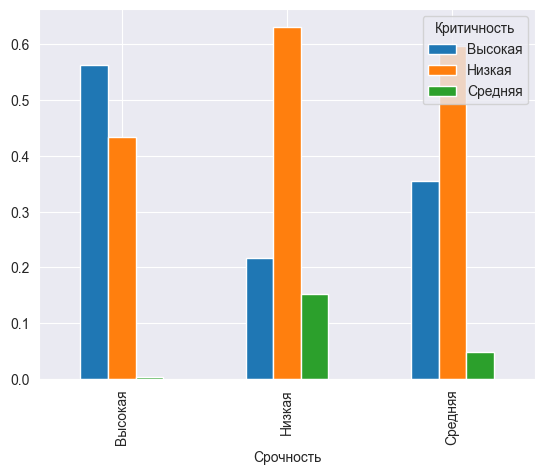

In [55]:
ct = pd.crosstab(data['Срочность'], data['Критичность'], normalize="index")
ct.plot(kind='bar')

Разбиение данных

In [56]:
import re
def clean(t):
    t = str(t).lower()
    t = t.split('добавил комментарий')[0]
    t = re.sub(r'тема письма:|инн:', ' ', t)
    t = re.sub(r'\d+', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

data['text'] = data['Описание 2'].map(clean)
data['text']

3       по этому отправлению, оператор не принял письм...
5       по номеру договора при вводе отправителя текст...
8                                               пользо---
10      здравствуйте. коллеги, ответ необходимо предос...
11      здравствуйте. коллеги, ответ необходимо предос...
                              ...                        
1920    сервис трекинга /другое текст письма: тематика...
1921    акция с промокодами/клиент не может оплатить п...
1924    сервис трекинга /другое текст письма: тематика...
1925    сервис трекинга /другое текст письма: тематика...
1927    услуги для населения/самостоятельная регистрац...
Name: text, Length: 1229, dtype: str

In [80]:
features = ['text', 'Услуга', 'Компонент услуги 1 уровня', 'Пользователь']
X = data[features]
y = data['Вид запроса']

In [81]:
print('Пустых text:', (data['text'] == '').sum())

conf = data.groupby('text')['Вид запроса'].nunique()
print('Текстов с разными видами:', (conf > 1).sum())
print('Повторов text:', data['text'].duplicated().sum())
conflict_texts = conf[conf > 1].index # конфилкатные вообще не входят ни один вариант

data_m = data[(data['text'] != '') & (~data['text'].isin(conflict_texts))]
data_m = data_m.drop_duplicates(subset='text', keep='first').copy()

print(data.shape, '->', data_m.shape)

Пустых text: 0
Текстов с разными видами: 6
Повторов text: 45
(1229, 36) -> (1178, 36)


In [82]:
from sklearn.model_selection import train_test_split
X = data_m[features]
y = data_m['Вид запроса']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(X_train.shape, X_test.shape)

(942, 4) (236, 4)


In [83]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_union
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score, accuracy_score, classification_report

cat_cols = ['Услуга', 'Компонент услуги 1 уровня', 'Пользователь']

text_vec = make_union(
    TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True),
    TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=2, sublinear_tf=True),
)# редкое слово - больший вес

prep = ColumnTransformer([
    ('1', text_vec, 'text'),
    ('2', OneHotEncoder(handle_unknown='ignore'), cat_cols),
])

model = Pipeline([
    ('prep', prep),
    ('clf', LogisticRegression(max_iter=2000, C=10, class_weight='balanced')),
])

In [84]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(model, X_train, y_train, cv=cv)# здесь модель обучилась fit transform


In [85]:
print('accuracy :', accuracy_score(y_train, y_pred_cv))
print('macro-F1 :', f1_score(y_train, y_pred_cv, average='macro'))
print(classification_report(y_train, y_pred_cv))

accuracy : 0.6358811040339702
macro-F1 : 0.590575572121402
                                                        precision    recall  f1-score   support

                   Автодобавление почтовых отправлений       0.68      0.50      0.58        30
                               Импорт списков из ЛК ЮЛ       0.41      0.52      0.46        77
            Импорт списков из архива ф.103 (zip-архив)       0.31      0.24      0.27        42
                                        Личный кабинет       0.70      0.41      0.52        34
                              Отслеживание отправлений       0.72      0.80      0.76       181
Ошибка в приложении (восстановление работоспособности)       0.59      0.70      0.64        67
                    Ошибки загрузки страницы/зависания       0.40      0.33      0.36        51
                                      Письма\бандероли       0.52      0.55      0.53        44
             Проблема с QR-код(подключение/отключение)       0.85      0.89 

Подбор гиперпараметров

In [86]:
for C in [1, 3, 10, 30]:
    model.set_params(clf__C=C)
    pred = cross_val_predict(model, X_train, y_train, cv=cv)
    print('C =', C,
          '| macro-F1 =', round(f1_score(y_train, pred, average='macro'), 3),
          '| accuracy =', round(accuracy_score(y_train, pred), 3))


C = 1 | macro-F1 = 0.572 | accuracy = 0.609
C = 3 | macro-F1 = 0.586 | accuracy = 0.63
C = 10 | macro-F1 = 0.591 | accuracy = 0.636
C = 30 | macro-F1 = 0.594 | accuracy = 0.642


In [87]:
model.set_params(clf__C=10)
y_pred_cv = cross_val_predict(model, X_train, y_train, cv=cv)

from sklearn.metrics import confusion_matrix
labels = sorted(y_train.unique())
cm = confusion_matrix(y_train, y_pred_cv, labels=labels)
pairs = []
for i, a in enumerate(labels):
    for j, b in enumerate(labels):
        if i != j and cm[i, j] > 0:
            pairs.append((cm[i, j], a, b))
pairs.sort(reverse=True)

for n, a, b in pairs[:10]:
    print(n, '| истина:', a, '| предсказано:', b)

22 | истина: Формирование и закрытие емкостей | предсказано: Импорт списков из ЛК ЮЛ
19 | истина: Ошибки загрузки страницы/зависания | предсказано: Импорт списков из ЛК ЮЛ
18 | истина: Проблема с авторизацией/ЭЗП/Бонусами/Доверенностями | предсказано: Ошибка в приложении (восстановление работоспособности)
17 | истина: Письма\бандероли | предсказано: Отслеживание отправлений
17 | истина: Личный кабинет | предсказано: Отслеживание отправлений
17 | истина: Импорт списков из архива ф.103 (zip-архив) | предсказано: Импорт списков из ЛК ЮЛ
16 | истина: Отслеживание отправлений | предсказано: Письма\бандероли
15 | истина: Электронные обращения | предсказано: Отслеживание отправлений
15 | истина: Отслеживание отправлений | предсказано: Электронные обращения
14 | истина: Импорт списков из ЛК ЮЛ | предсказано: Формирование и закрытие емкостей


In [88]:
res = X_train.copy()
res['истина'] = y_train
res['предсказано'] = y_pred_cv

# ошибки: емкости -> ЛК ЮЛ
mask = (res['истина'] == 'Формирование и закрытие емкостей') & (res['предсказано'] == 'Импорт списков из ЛК ЮЛ')
print('ОШИБКИ:', mask.sum())
for _, r in res[mask].head(5).iterrows():
    print(r['Услуга'], '|', r['Компонент услуги 1 уровня'])
    print(r['text'][:300])
    print('---')

# для сравнения: верно распознанные ЛК ЮЛ
ok = (res['истина'] == 'Импорт списков из ЛК ЮЛ') & (res['предсказано'] == 'Импорт списков из ЛК ЮЛ')
print('\nВЕРНЫЕ ЛК ЮЛ:', ok.sum())
for _, r in res[ok].head(5).iterrows():
    print(r['Услуга'], '|', r['Компонент услуги 1 уровня'])
    print(r['text'][:300])
    print('---')

ОШИБКИ: 22
Партионный прием (Priem.pochta.ru) | Сервис партионного приема
принятое .. в партионном приёме рпо не проходит в исходящую ёмкость и не отображается в журнале рпо. индекс опс: номер окна: номер телефона для связи с опс: последовательность действий: время возникновения ошибки: .. :
---
Партионный прием (Priem.pochta.ru) | Сервис партионного приема
добрый день! не можем принять простые письма по спискам, списков шт, и все не можем принять. организация ; управление финансов администрации г. магнитогорска. индекс опс: номер окна: номер телефона для связи с опс: последовательность действий: прием ппк от юл время возникновения ошибки: .. :
---
Партионный прием (Priem.pochta.ru) | Сервис партионного приема
здравствуйте , партионные письма от ,, не идентифицируются распр маршрутный лист ,,,,,,,,, мту ространснадзора маршрутный лист мфц полюс маршрутный лист гибдд идентификатор -, -,,- индекс опс: номер окна: номер телефона для связи с опс: последовательность действий: . время возник

In [89]:
#пробуем посичтить данные(выстраиваем гипотизы)
def clean2(t):
    t = str(t).lower().replace('ё', 'е')
    t = t.split('добавил комментарий')[0]
    # шаблонные фразы формы
    for phrase in ['подробное описание возникшей проблемы',
                   'последовательность действий',
                   'индекс опс',
                   'номер окна',
                   'номер телефона для связи с опс',
                   'время возникновения ошибки',
                   'тема письма', 'инн']:
        t = t.replace(phrase, ' ')
    t = re.sub(r'[^\w\s]|\d+|_', ' ', t)   # знаки препинания и цифры
    return re.sub(r'\s+', ' ', t).strip()

data_m['text'] = data_m['Описание 2'].map(clean2)

# тот же сплит, но с новым текстом
X_train = data_m.loc[X_train.index, features].copy()
X_test = data_m.loc[X_test.index, features].copy()
X_train[cat_cols] = X_train[cat_cols].fillna('Не указан')

y_pred_cv = cross_val_predict(model, X_train, y_train, cv=cv)
print('accuracy :', accuracy_score(y_train, y_pred_cv))
print('macro-F1 :', f1_score(y_train, y_pred_cv, average='macro'))


accuracy : 0.6411889596602972
macro-F1 : 0.5973786247814036


In [90]:
# гипотеза 2 категориальные признаки не помогают
prep_text = ColumnTransformer([('text', text_vec, 'text')])

model_text = Pipeline([
    ('prep', prep_text),
    ('clf', LogisticRegression(max_iter=2000, C=10, class_weight='balanced')),
])

pred_text = cross_val_predict(model_text, X_train, y_train, cv=cv)
print('accuracy :', accuracy_score(y_train, pred_text))
print('macro-F1 :', f1_score(y_train, pred_text, average='macro'))

accuracy : 0.5690021231422505
macro-F1 : 0.5120569076880859


In [91]:
#подбираем threshold
model.set_params(clf__C=10)
proba_cv = cross_val_predict(model, X_train, y_train, cv=cv, method='predict_proba')

classes = np.array(sorted(y_train.unique()))
pred = classes[proba_cv.argmax(axis=1)]
conf = proba_cv.max(axis=1)
correct = (pred == y_train.values)

rows = []
for t in [0.0, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    m = conf >= t
    rows.append({
        'порог': t,
        'доля обработанных': round(m.mean(), 2),
        'accuracy среди обработанных': round(correct[m].mean(), 3),
    })
pd.DataFrame(rows)

,порог,доля обработанных,accuracy среди обработанных
0,0.0,1.00,0.641
1,0.3,0.98,0.651
2,0.4,0.85,0.694
3,0.5,0.69,0.737
4,0.6,0.52,0.766
5,0.7,0.40,0.830
6,0.8,0.28,0.882


хороший вариант 69% отвечает модель, точность 74%

In [92]:
# 1. обращения вне 15 видов, с той же очисткой текста
other = df[~df['Вид запроса'].isin(top15.index)].dropna(subset=['Описание 2']).copy()
other['text'] = other['Описание 2'].map(clean2)
other[cat_cols] = other[cat_cols].fillna('Не указан')
print('вне набора:', len(other), '| из них Прочее:', (other['Вид запроса'] == 'Прочее').sum())

# 2. обучаем модель на train и считаем уверенность на этих обращениях
model.fit(X_train, y_train)
conf_other = model.predict_proba(other[features]).max(axis=1)

# 3. какая доля получила уверенность выше порога
rows = []
for t in [0.4, 0.5, 0.6, 0.7, 0.8]:
    rows.append({
        'порог': t,
        'вне набора, доля с уверенностью >= порога': round((conf_other >= t).mean(), 2),
    })
pd.DataFrame(rows)

вне набора: 694 | из них Прочее: 316


,порог,"вне набора, доля с уверенностью >= порога"
0,0.4,0.62
1,0.5,0.44
2,0.6,0.33
3,0.7,0.20
4,0.8,0.11


In [93]:
X_test = X_test.copy()
X_test[cat_cols] = X_test[cat_cols].fillna('Не указан')

model.fit(X_train, y_train)
proba = model.predict_proba(X_test)
pred = model.classes_[proba.argmax(axis=1)]
conf = proba.max(axis=1)

# тексты test, которые целиком совпадают с текстами train
new = ~X_test['text'].isin(set(X_train['text'])).values
print('совпадающих текстов:', (~new).sum(), 'из', len(X_test))

for name, m in [('весь test', np.ones(len(X_test), bool)), ('только новые тексты', new)]:
    print(name, '| n =', m.sum(),
          '| accuracy =', round(accuracy_score(y_test[m], pred[m]), 3),
          '| macro-F1 =', round(f1_score(y_test[m], pred[m], average='macro'), 3))

print(classification_report(y_test, pred))

correct = (pred == y_test.values)
rows = []
for t in [0.0, 0.5, 0.7]:
    m = conf >= t
    rows.append({'порог': t, 'доля обработанных': round(m.mean(), 2),
                 'accuracy среди обработанных': round(correct[m].mean(), 3)})
pd.DataFrame(rows)

совпадающих текстов: 2 из 236
весь test | n = 236 | accuracy = 0.661 | macro-F1 = 0.636
только новые тексты | n = 234 | accuracy = 0.658 | macro-F1 = 0.632
                                                        precision    recall  f1-score   support

                   Автодобавление почтовых отправлений       0.71      0.62      0.67         8
                               Импорт списков из ЛК ЮЛ       0.43      0.47      0.45        19
            Импорт списков из архива ф.103 (zip-архив)       0.33      0.36      0.35        11
                                        Личный кабинет       0.44      0.44      0.44         9
                              Отслеживание отправлений       0.71      0.80      0.75        45
Ошибка в приложении (восстановление работоспособности)       0.69      0.53      0.60        17
                    Ошибки загрузки страницы/зависания       0.36      0.38      0.37        13
                                      Письма\бандероли       0.64      0.64

,порог,доля обработанных,accuracy среди обработанных
0,0.0,1.00,0.661
1,0.5,0.68,0.775
2,0.7,0.40,0.883


Линия поддержки

In [95]:
import joblib
model.set_params(clf__C=10)
model.fit(X_train, y_train)
joblib.dump(model, 'model_category_v1.joblib')

['model_category_v1.joblib']

In [97]:
print(list(df.columns))

['Номер запроса', 'Дата регистрации', 'Статус', 'Пользователь', 'Услуга', 'Компонент услуги 1 уровня', 'Вид запроса', 'Тип запроса', 'Описание 2', 'Критичность', 'Срочность', 'Приоритет', 'Класс обслуживания', 'Часовой пояс запроса', 'Норматив ное время обработки (SLA)', 'Плановое время выполнения', 'Крайний срок обработки', 'Фактическое время выполнения', 'Фактическая длительность выполнения запроса (SLA)', 'Просрочен?*', 'Время входа в статус', 'Дата последнего изменения', 'Суммарное время реакции 1 линии', 'Суммарное время работы 1 линии', 'Суммарное время реакции 2 линии', 'Суммарное время работы 2 линии', 'Суммарное время реакции 3 линии', 'Суммарное время работы 3 линии', 'Суммарное время реакции 4 линии', 'Суммарное время работы 4 линии', 'Суммарное время уточнений', 'Результат работ', 'Кем решен (группа)', 'Количество уточнений']


In [98]:
line_col = 'Кем решен (группа)'
print(data_m[line_col].value_counts(dropna=False))

y_line_train = data_m.loc[X_train.index, line_col].fillna('Не указана')
y_line_test = data_m.loc[X_test.index, line_col].fillna('Не указана')

model_line = Pipeline([
    ('prep', prep),
    ('clf', LogisticRegression(max_iter=2000, C=10, class_weight='balanced')),
])

# CV на train
pred_l = cross_val_predict(model_line, X_train, y_line_train, cv=cv)
print('CV accuracy:', round(accuracy_score(y_line_train, pred_l), 3),
      '| macro-F1:', round(f1_score(y_line_train, pred_l, average='macro'), 3))
print('самая частая группа (простой ориентир):',
      round(y_line_train.value_counts(normalize=True).iloc[0], 3))

# один раз на test, без подбора
model_line.fit(X_train, y_line_train)
pred_lt = model_line.predict(X_test)
print('TEST accuracy:', round(accuracy_score(y_line_test, pred_lt), 3),
      '| macro-F1:', round(f1_score(y_line_test, pred_lt, average='macro'), 3))
print(classification_report(y_line_test, pred_lt))

Кем решен (группа)
(1 линия)    676
(2 линия)    380
(3 линия)    122
Name: count, dtype: int64
CV accuracy: 0.721 | macro-F1: 0.657
самая частая группа (простой ориентир): 0.569
TEST accuracy: 0.742 | macro-F1: 0.673
              precision    recall  f1-score   support

   (1 линия)       0.84      0.84      0.84       140
   (2 линия)       0.63      0.58      0.60        76
   (3 линия)       0.52      0.65      0.58        20

    accuracy                           0.74       236
   macro avg       0.66      0.69      0.67       236
weighted avg       0.74      0.74      0.74       236



Объяснение выбора линии

In [99]:
hist_all = data_m.loc[X_train.index].copy()
hist_all[line_col] = hist_all[line_col].fillna('Не указана')

def explain_line(category):
    s = hist_all.loc[hist_all['Вид запроса'] == category, line_col].value_counts(normalize=True)
    return ', '.join(f'{k}: {v:.0%}' for k, v in s.items())

print(explain_line('Формирование и закрытие емкостей'))

(2 линия): 53%, (3 линия): 38%, (1 линия): 9%


In [109]:
import joblib, sqlite3

model.set_params(clf__C=10)
model.fit(X_train, y_train)
joblib.dump(model, 'models/model_category_v1.joblib')

model_line.fit(X_train, y_line_train)
joblib.dump(model_line, 'models/model_line_v1.joblib')

# история для объяснения выбора линии
line_hist = data_m.loc[X_train.index, ['Вид запроса', line_col]].copy()
joblib.dump(line_hist, 'models/line_history.joblib')

# значения для выпадающих списков
joblib.dump({'services': sorted(X_train['Услуга'].unique()),
             'components': sorted(X_train['Компонент услуги 1 уровня'].unique())},
            'models/options.joblib')

# хранение данных для аналитики
conn = sqlite3.connect('data/tickets.db')
df.to_sql('tickets', conn, if_exists='replace', index=False)
conn.close()

import sklearn, pandas, streamlit
print(sklearn.__version__, pandas.__version__, streamlit.__version__)

1.8.0 3.0.1 1.65.0


In [110]:
import importlib.metadata as md

pkgs = ['streamlit', 'scikit-learn', 'pandas', 'numpy', 'joblib', 'openpyxl', 'matplotlib', 'seaborn']
for p in pkgs:
    print(f'{p}=={md.version(p)}')

streamlit==1.65.0
scikit-learn==1.8.0
pandas==3.0.1
numpy==2.4.3
joblib==1.5.3
openpyxl==3.1.5
matplotlib==3.10.8
seaborn==0.13.2
